# **Scikit**

En este apartado, se va a realizar el preprocesamiento de los datos limpios obtenidos después del ***Análisis Exploratorio de los Datos***. Posterior a ello, se implementará el modelo **MLP (Multilayer Perceptron) de Clasificación** con **SCIKIT-LEARN**.

## **Librerías**

In [1]:
from imblearn.ensemble import BalancedRandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
import pandas as pd
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import time
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV
import warnings
warnings.filterwarnings("ignore")
from imblearn.over_sampling import SMOTE
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, auc, RocCurveDisplay
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

## **Base de datos**

In [2]:
dataclean = pd.read_csv('../data/datalimpia.csv')

## **Preprocesamiento**

En el campo del *Machine Learning y Deep Learning*, es fundamental identificar las variables que explican con mayor peso la variable objetivo, ya que son las que más valor aportan a los modelos. Para esta tarea, se pueden utilizar algoritmos como *Random Forest o XGBoost*, que proporcionan métricas sobre la importancia de cada característica (feature importance).



Sin embargo, un problema común ocurre cuando las bases de datos presentan un desbalanceo considerable en la variable objetivo, una situación que debe tratarse para no sesgar los resultados. En este proyecto, se abordará este problema implementando el modelo `BalancedRandomForestClassifier`, el cual '[...] se diferencia de un bosque aleatorio clásico en el hecho de que extraerá una muestra bootstrap de la clase minoritaria y tomará una muestra con reemplazo de la misma cantidad de muestras de la clase mayoritaria.' (The imbalanced-learn developers, n.d.). A partir de esto, se implementará el modelo para buscar la obtener la significancia de cada variable explicativa manteniendo una mejor distribución entre la clases.

In [3]:
# Separación de variables predictoras y variable objetivo
X_brf = dataclean.drop('default', axis=1)
y_brf = dataclean['default']

In [4]:
# Codificación de variables categóricas según su naturaleza
ord_cols = ['grade', 'addr_state']
nom_cols = [col for col in X_brf.select_dtypes(include='object').columns if col not in ord_cols]

for col in ord_cols:
    X_brf[col] = LabelEncoder().fit_transform(X_brf[col])
    
encoder = OneHotEncoder(sparse_output=False, drop='first')
X_nominal_encoded = pd.DataFrame(
    encoder.fit_transform(X_brf[nom_cols]),
    columns=encoder.get_feature_names_out(nom_cols)
)

X_preproc = pd.concat([X_brf.drop(columns=nom_cols).reset_index(drop=True),
                       X_nominal_encoded.reset_index(drop=True)], axis=1)

In [5]:
brf = BalancedRandomForestClassifier(n_estimators=100, random_state=21,
                                     replacement=False, n_jobs=-1)

brf.fit(X_preproc, y_brf)

importances = pd.Series(brf.feature_importances_, index=X_preproc.columns)
importances.sort_values(ascending=False, inplace=True)

threshold = 0.01

selected_features = importances[importances > threshold].index.tolist()

print("Cantidad de variables seleccionadas:", len(selected_features))
print("Variables seleccionadas:", selected_features)

Cantidad de variables seleccionadas: 22
Variables seleccionadas: ['dti', 'grade', 'tot_hi_cred_lim', 'annual_inc', 'funded_amnt', 'debt_settlement_flag_Y', 'total_il_high_credit_limit', 'addr_state', 'mths_since_recent_bc', 'num_il_tl', 'mo_sin_rcnt_rev_tl_op', 'mths_since_recent_inq', 'num_actv_rev_tl', 'mo_sin_rcnt_tl', 'emp_length', 'term', 'num_tl_op_past_12m', 'mort_acc', 'inq_last_6mths', 'tot_coll_amt', 'num_accts_ever_120_pd', 'delinq_2yrs']


Como resultado, se obtuvo que entre el conjunto total de datos disponibles, la información de **22** varias resultó ser la más siginificativa o relevante.

Ahora, vamos a implementar **MLP** con estas variables seleccionadas.

## **Modelo MLP**

In [6]:
X_final = X_preproc[selected_features].copy()

numcolsfinal = X_final.select_dtypes(include=np.number).columns.tolist()
scaler = StandardScaler()
X_final[numcolsfinal] = scaler.fit_transform(X_final[numcolsfinal])

Para corregir el severo desbalance de clases (80/20), se empleó la técnica de sobremuestreo **SMOTE** para generar observaciones sintéticas de la clase minoritaria. Dado que el conjunto de datos balanceado resultante era muy extenso, la optimización de hiperparámetros se realizó sobre una muestra representativa del mismo.

Posteriormente, el modelo final se entrenó utilizando estos hiperparámetros óptimos sobre la totalidad de los datos.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X_final, y_brf, test_size=0.2, random_state=21, stratify=y_brf
)

sm = SMOTE(random_state=21)
X_train_bal, y_train_bal = sm.fit_resample(X_train, y_train)

tammuestra = 0.1 

X_sample, _, y_sample, _ = train_test_split(
    X_train_bal,
    y_train_bal,
    train_size=tammuestra,
    stratify=y_train_bal, 
    random_state=21
)

A continuación, podemos observar las distintas opciones que se dio por hiperparámetro en el paramgrid.

In [8]:
mlp = MLPClassifier(random_state=21, early_stopping=True)

param_grid = {
    'hidden_layer_sizes': [(10,), (50,), (100,)],
    'alpha': [0.001, 0.01, 0.1],  
    'max_iter': [150, 200]
}

grid_search = GridSearchCV(
    estimator=mlp,
    param_grid=param_grid,
    scoring='recall',       
    cv=3,               
    n_jobs=-1,
    verbose=0
)

En primer lugar, veamos cuánto tiempo demora en encontrar los mejores hiperparámetros basado en una muestra representativa previamente balanceada.

In [9]:
start_time = time.time()
grid_search.fit(X_sample, y_sample)
train_time = time.time() - start_time
print("Tiempo GridSearch (sample):", train_time)

Tiempo GridSearch (sample): 135.04896450042725


In [10]:
best_params = grid_search.best_params_
print("Mejores hiperparámetros encontrados:", best_params)

Mejores hiperparámetros encontrados: {'alpha': 0.001, 'hidden_layer_sizes': (100,), 'max_iter': 150}


Implementando ahora el modelo con la base completa y los hiperarámetros seleccionados, evidenciamos el tiempo de ejecución del conjunto de entrenamiento.

In [11]:
bestmlp_final = MLPClassifier(**best_params, random_state=21, early_stopping=True)
start_time = time.time()
bestmlp_final.fit(X_train_bal, y_train_bal)
final_train_time = time.time() - start_time
print("Tiempo entrenamiento final:", final_train_time)

Tiempo entrenamiento final: 867.7565214633942


Finalmente, el tiempo de ejecución del conjunto de prueba.

In [12]:
start_time_pred = time.time()
y_pred = bestmlp_final.predict(X_test)
y_proba = bestmlp_final.predict_proba(X_test)[:, 1]
test_time = time.time() - start_time_pred
print("Tiempo predicción:", test_time)

Tiempo predicción: 1.176584005355835


### **Métricas y valores resultantes**

In [13]:
metrics = {
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision':precision_score(y_test, y_pred),
    'Recall':recall_score(y_test, y_pred),
    'F1-score':f1_score(y_test, y_pred),
    'ROC AUC':roc_auc_score(y_test, y_proba)
}

scikitmetrics = pd.DataFrame([metrics])
print(scikitmetrics)

   Accuracy  Precision    Recall  F1-score   ROC AUC
0  0.750325   0.397625  0.486874  0.437747  0.727849


Para este ejercicio, se hará enfásis en el análisis de las métricas **Recall y ROC AUC**, dado que resultan fundamentales para evaluar la capacidad del modelo de identificar correctamente los casos positivos, así como su eficacia al diferenciar entre las clases positiva y negativa.

En este sentido, el valor obtenido para **Recall** fue de aproximadamente `0.49`, lo que indica que **el modelo logró identificar correctamente el 49% de los casos positivos** presentes en los datos. Por su parte, la métrica **ROC AUC** alcanzó un valor de `0.73` aproximado, lo cual refleja que **el modelo posee una capacidad de distinción entre clases superior a la del azar (0.5)**, aunque aún distante de un desempeño óptimo.

En términos generales, los resultados muestran que el modelo no presenta un comportamiento sobresaliente; sin embargo, puede considerarse que su desempeño es moderado.

### **Matriz de confusión**

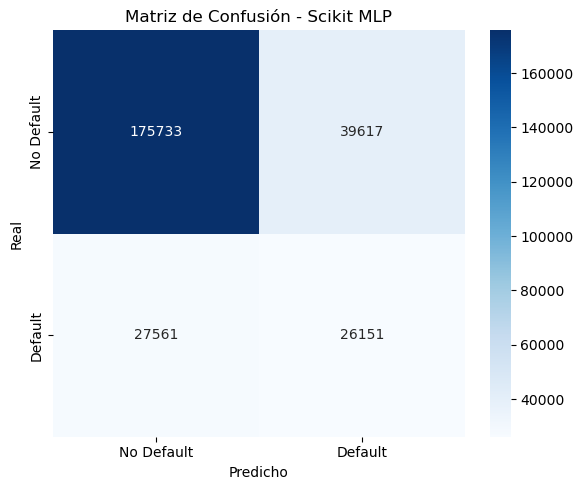

In [14]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Default","Default"],
            yticklabels=["No Default","Default"])
plt.title("Matriz de Confusión - Scikit MLP")
plt.ylabel("Real")
plt.xlabel("Predicho")
plt.tight_layout()
plt.savefig("confusion_matrix_scikit.png")
plt.show()
plt.close()

Los resultados de la matriz de confusión se alinean con lo observado previamente en las métricas de evaluación. Entre las predicciones correctas, el modelo identificó `175733` casos pertenecientes a la clase 0 (pagado) y `26151` correspondientes a la clase 1 (default). No obstante, se observa que `27561` casos de la clase positiva no fueron reconocidos adecuadamente, lo que implica un número considerable de falsos negativos.

### **Curva ROC**

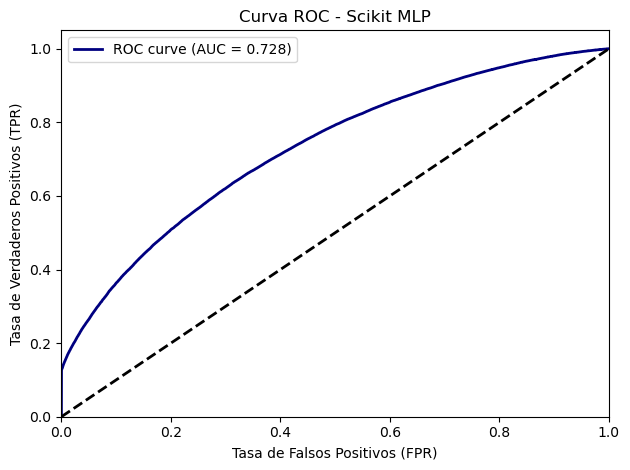

In [15]:
y_prob = bestmlp_final.predict_proba(X_test)[:, 1]  

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='navy', lw=2, label='ROC curve (AUC = %0.3f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='black', lw=2, linestyle='--')  
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("Tasa de Falsos Positivos (FPR)")
plt.ylabel("Tasa de Verdaderos Positivos (TPR)")
plt.title("Curva ROC - Scikit MLP")
plt.legend()
plt.tight_layout()
plt.savefig("roc_curve_scikit.png")
plt.show()
plt.close()

Como se esperaba, la curva ROC se encuentra por encima de la diagonal, lo cual indica que el modelo tiene capacidad de distinción. Con un AUC de `0.73` aproximado, se puede reafirmar que el rendimiento del modelo es significativamente mejor que el de una predicción aleatoria.

In [16]:
output_data = {
    "best_table": metrics,
    "train_time": final_train_time,
    "test_time": test_time,
    "confusion_matrix": cm,
    "roc_auc": roc_auc,
    "confusion_matrix_img": "confusion_matrix_scikit.png",
    "roc_curve_img": "roc_curve_scikit.png"
}

with open("best_model_scikit.pkl", "wb") as f:
    pickle.dump(output_data, f)


## **LIME**

In [16]:
from lime.lime_tabular import LimeTabularExplainer
import numpy as np

In [17]:
y_test_np = y_test.values  # ahora es un array NumPy
misclassified_idx = np.where(y_pred != y_test_np)[0]

In [ ]:
instances_to_explain = misclassified_idx[:2]

In [ ]:
explainer = LimeTabularExplainer(
    training_data=np.array(X_train),
    feature_names=X_train.columns,
    class_names=['Fully Paid', 'Charged Off'],
    mode='classification'
)

In [ ]:
for idx in instances_to_explain:
    exp = explainer.explain_instance(
        data_row=X_test.iloc[idx].values,
        predict_fn=bestmlp_final.predict_proba
    )  

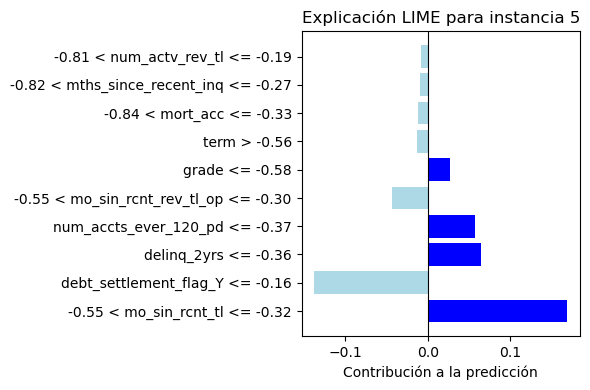

In [ ]:
feature_names, contributions = zip(*exp.as_list())
    
colors = ['blue' if c > 0 else 'lightblue' for c in contributions]
    
    # Gráfico de barras horizontal
plt.figure(figsize=(6,4))
plt.barh(feature_names, contributions, color=colors)
plt.xlabel('Contribución a la predicción')
plt.title(f'Explicación LIME para instancia {idx}')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

Este gráfico muestra la explicación local generada con LIME para la instancia 5, evidenciando las variables que más influyeron en la predicción. Las barras azul oscuro representan los factores que empujaron la predicción hacia Default (incumplimiento), siendo los más decisivos la actividad crediticia muy reciente (mo_sin_rcnt_tl) y un historial de pagos atrasados (num_accts_ever_120_pd). En contraste, las barras celestes reflejan variables asociadas con Fully Paid, destacando la ausencia de un acuerdo de liquidación de deuda (debt_settlement_flag_Y).

## **Referencia bibliográfica**

imbalanced-learn developers. (s. f.). *imbalanced_learn.ensemble.BalancedRandomForestClassifier*. Recuperado de la documentación de imbalanced-learn
